=== KFold (Validação Cruzada Tradicional) ===
Característica: Embaralha os dados aleatoriamente


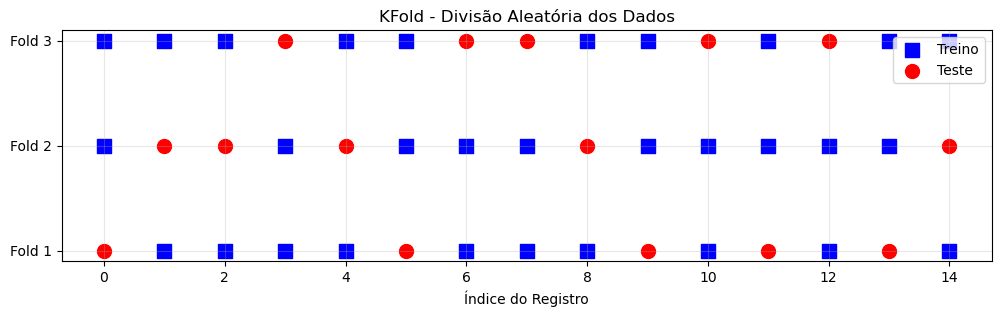


=== TimeSeriesSplit (Validação Temporal) ===
Característica: Preserva a ordem temporal dos dados


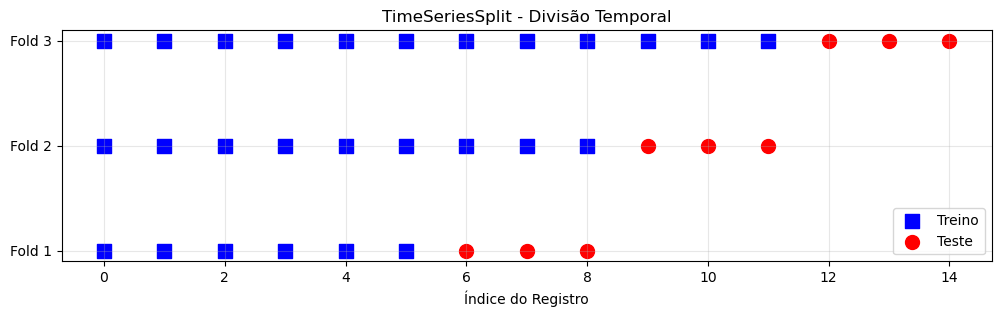


=== KFold ===
Fold 1: Treino [1, 2, 3, 4, 6, 7, 8, 10, 12, 14] | Teste [0, 5, 9, 11, 13]
Fold 2: Treino [0, 3, 5, 6, 7, 9, 10, 11, 12, 13] | Teste [1, 2, 4, 8, 14]
Fold 3: Treino [0, 1, 2, 4, 5, 8, 9, 11, 13, 14] | Teste [3, 6, 7, 10, 12]

=== TimeSeriesSplit ===
Fold 1: Treino [0, 1, 2, 3, 4, 5] | Teste [6, 7, 8]
Fold 2: Treino [0, 1, 2, 3, 4, 5, 6, 7, 8] | Teste [9, 10, 11]
Fold 3: Treino [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] | Teste [12, 13, 14]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, KFold

# Dados de exemplo (15 registros sequenciais)
X = np.array([[i] for i in range(15)])
y = np.array([i for i in range(15)])

folds = 3

# Criar os divisores (CORRIGIDO)
ts_cv = TimeSeriesSplit(n_splits=folds)
kf_cv = KFold(n_splits=folds, shuffle=True, random_state=42)  # shuffle=True para usar random_state

# Visualizar os folds
def plot_folds(cv, title):
    plt.figure(figsize=(12, 3))
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X)):
        # Plotar treino
        plt.scatter(train_idx, [fold_idx] * len(train_idx), 
                   color='blue', marker='s', s=100, label='Treino' if fold_idx == 0 else "")
        
        # Plotar teste
        plt.scatter(test_idx, [fold_idx] * len(test_idx), 
                   color='red', marker='o', s=100, label='Teste' if fold_idx == 0 else "")
    
    plt.yticks(range(folds), [f'Fold {i+1}' for i in range(folds)])
    plt.xlabel('Índice do Registro')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plotar KFold (validação cruzada tradicional)
print("=== KFold (Validação Cruzada Tradicional) ===")
print("Característica: Embaralha os dados aleatoriamente")
plot_folds(kf_cv, 'KFold - Divisão Aleatória dos Dados')

# Plotar TimeSeriesSplit (validação temporal)
print("\n=== TimeSeriesSplit (Validação Temporal) ===")
print("Característica: Preserva a ordem temporal dos dados")
plot_folds(ts_cv, 'TimeSeriesSplit - Divisão Temporal')

# Verificar índices de cada fold
print("\n=== KFold ===")
for fold, (train_idx, test_idx) in enumerate(kf_cv.split(X)):
    print(f"Fold {fold+1}: Treino {train_idx.tolist()} | Teste {test_idx.tolist()}")

print("\n=== TimeSeriesSplit ===")
for fold, (train_idx, test_idx) in enumerate(ts_cv.split(X)):
    print(f"Fold {fold+1}: Treino {train_idx.tolist()} | Teste {test_idx.tolist()}")

=== KFold (Validação Cruzada Tradicional) ===


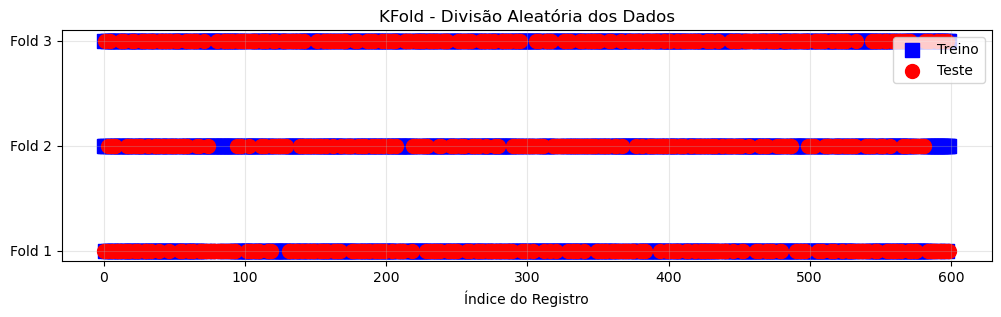


=== TimeSeriesSplit (Validação Temporal) ===


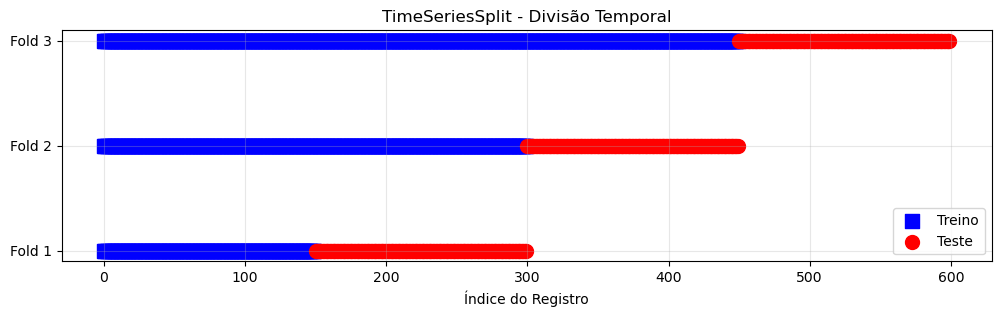

🔍 ANALISANDO DATA LEAKAGE TEMPORAL...

ANÁLISE COMPARATIVA: KFold vs TimeSeriesSplit
ACCURACY    :
  KFold: 0.9233 | TimeSeries: 0.9244
  Diferença: -0.0011 (Diferença aceitável ✅)
PRECISION   :
  KFold: 0.9408 | TimeSeries: 0.9404
  Diferença: +0.0004 (Diferença aceitável ✅)
RECALL      :
  KFold: 0.9018 | TimeSeries: 0.9120
  Diferença: -0.0102 (Diferença aceitável ✅)
F1          :
  KFold: 0.9208 | TimeSeries: 0.9252
  Diferença: -0.0044 (Diferença aceitável ✅)


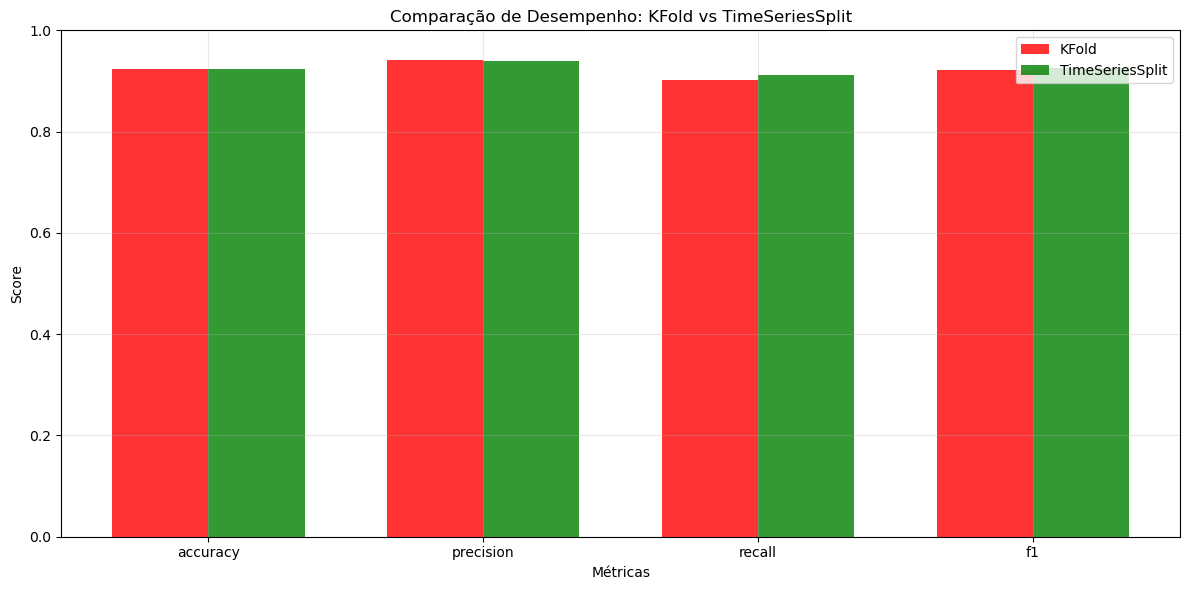


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
ALERTAS IMPORTANTES:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
⚠️  KFold COM shuffle: Gera DATA LEAKAGE em séries temporais!
✅ TimeSeriesSplit: Preserva a estrutura temporal dos dados
📊 Métricas do KFold tendem a ser SUPERESTIMADAS
🎯 Para séries temporais reais, use SEMPRE TimeSeriesSplit


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            confusion_matrix, classification_report, mean_absolute_error,
                            mean_squared_error)
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=600, n_features=5, n_informative=3, 
                          n_redundant=1, n_classes=2, random_state=42)

folds = 3

# Criar os divisores
ts_cv = TimeSeriesSplit(n_splits=folds)
kf_cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Visualizar os folds
def plot_folds(cv, title):
    plt.figure(figsize=(12, 3))
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X)):
        plt.scatter(train_idx, [fold_idx] * len(train_idx), 
                   color='blue', marker='s', s=100, label='Treino' if fold_idx == 0 else "")
        plt.scatter(test_idx, [fold_idx] * len(test_idx), 
                   color='red', marker='o', s=100, label='Teste' if fold_idx == 0 else "")
    
    plt.yticks(range(folds), [f'Fold {i+1}' for i in range(folds)])
    plt.xlabel('Índice do Registro')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plotar divisões
print("=== KFold (Validação Cruzada Tradicional) ===")
plot_folds(kf_cv, 'KFold - Divisão Aleatória dos Dados')

print("\n=== TimeSeriesSplit (Validação Temporal) ===")
plot_folds(ts_cv, 'TimeSeriesSplit - Divisão Temporal')

# # Função para avaliar métricas de desempenho
# def evaluate_model(cv, X, y, model, cv_name):
#     print(f"\n{'='*60}")
#     print(f"AVALIAÇÃO: {cv_name}")
#     print(f"{'='*60}")
    
#     fold_metrics = {
#         'accuracy': [], 'precision': [], 'recall': [], 
#         'f1': [], 'mae': [], 'mse': []
#     }
    
#     for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
#         X_train, X_test = X[train_idx], X[test_idx]
#         y_train, y_test = y[train_idx], y[test_idx]
        
#         # Treinar e prever
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         y_pred_proba = model.predict_proba(X_test)[:, 1]
        
#         # Calcular métricas
#         accuracy = accuracy_score(y_test, y_pred)
#         precision = precision_score(y_test, y_pred, zero_division=0)
#         recall = recall_score(y_test, y_pred, zero_division=0)
#         f1 = f1_score(y_test, y_pred, zero_division=0)
#         mae = mean_absolute_error(y_test, y_pred_proba)
#         mse = mean_squared_error(y_test, y_pred_proba)
        
#         # Armazenar métricas
#         fold_metrics['accuracy'].append(accuracy)
#         fold_metrics['precision'].append(precision)
#         fold_metrics['recall'].append(recall)
#         fold_metrics['f1'].append(f1)
#         fold_metrics['mae'].append(mae)
#         fold_metrics['mse'].append(mse)
        
#         print(f"\nFold {fold+1}:")
#         print(f"  Treino: samples {len(X_train)}, Teste: samples {len(X_test)}")
#         print(f"  Acurácia:   {accuracy:.4f}")
#         print(f"  Precisão:   {precision:.4f}")
#         print(f"  Recall:     {recall:.4f}")
#         print(f"  F1-Score:   {f1:.4f}")
#         print(f"  MAE:        {mae:.4f}")
#         print(f"  MSE:        {mse:.4f}")
        
#         # Matriz de confusão para último fold
#         if fold == folds - 1:
#             cm = confusion_matrix(y_test, y_pred)
#             print(f"\n  Matriz de Confusão (Fold {fold+1}):")
#             print(f"  {cm[0]}")
#             print(f"  {cm[1]}")
    
#     # Métricas consolidadas
#     print(f"\n{'='*40}")
#     print(f"RESUMO FINAL: {cv_name}")
#     print(f"{'='*40}")
#     for metric, values in fold_metrics.items():
#         mean_val = np.mean(values)
#         std_val = np.std(values)
#         print(f"{metric.upper():<12}: {mean_val:.4f} ± {std_val:.4f}")
    
#     return fold_metrics

# Instanciar modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Avaliar ambos os métodos
print("🔍 ANALISANDO DATA LEAKAGE TEMPORAL...")
# kf_metrics = evaluate_model(kf_cv, X, y, model, "KFold (COM Data Leakage)")
# ts_metrics = evaluate_model(ts_cv, X, y, model, "TimeSeriesSplit (SEM Data Leakage)")

# Análise comparativa
print(f"\n{'='*60}")
print("ANÁLISE COMPARATIVA: KFold vs TimeSeriesSplit")
print(f"{'='*60}")

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    kf_mean = np.mean(kf_metrics[metric])
    ts_mean = np.mean(ts_metrics[metric])
    difference = kf_mean - ts_mean
    
    print(f"{metric.upper():<12}:")
    print(f"  KFold: {kf_mean:.4f} | TimeSeries: {ts_mean:.4f}")
    print(f"  Diferença: {difference:+.4f} {'(KFold SUPERESTIMA ⚠️)' if difference > 0.05 else '(Diferença aceitável ✅)'}")

# Visualizar comparação de desempenho
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
x_pos = np.arange(len(metrics_to_plot))

kf_means = [np.mean(kf_metrics[m]) for m in metrics_to_plot]
ts_means = [np.mean(ts_metrics[m]) for m in metrics_to_plot]

plt.figure(figsize=(12, 6))
bar_width = 0.35
plt.bar(x_pos - bar_width/2, kf_means, bar_width, label='KFold', alpha=0.8, color='red')
plt.bar(x_pos + bar_width/2, ts_means, bar_width, label='TimeSeriesSplit', alpha=0.8, color='green')

plt.xlabel('Métricas')
plt.ylabel('Score')
plt.title('Comparação de Desempenho: KFold vs TimeSeriesSplit')
plt.xticks(x_pos, metrics_to_plot)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Alertas finais
print(f"\n{'!'*80}")
print("ALERTAS IMPORTANTES:")
print(f"{'!'*80}")
print("⚠️  KFold COM shuffle: Gera DATA LEAKAGE em séries temporais!")
print("✅ TimeSeriesSplit: Preserva a estrutura temporal dos dados")
print("📊 Métricas do KFold tendem a ser SUPERESTIMADAS")
print("🎯 Para séries temporais reais, use SEMPRE TimeSeriesSplit")